<a href="https://colab.research.google.com/github/Asripramudiya/AI-Guesspic/blob/main/AQI2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install Library

In [ ]:
!pip install requests

# Import Library

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import (mean_absolute_error,mean_squared_error,mean_absolute_percentage_error)
import joblib

# Data Collection

In [ ]:
latitude = -7.7956
longitude = 110.3695

start_date = "2023-07-16"
end_date = "2026-07-16"

aqi_url = "https://air-quality-api.open-meteo.com/v1/air-quality"

aqi_params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": [
        "pm10",
        "pm2_5",
        "carbon_monoxide",
        "nitrogen_dioxide",
        "sulphur_dioxide",
        "ozone",
        "us_aqi"
    ],
    "timezone": "Asia/Jakarta"
}

response_aqi = requests.get(
    aqi_url,
    params=aqi_params,
    timeout=60
)

response_aqi.raise_for_status()

air_json = response_aqi.json()

df_aqi = pd.DataFrame(air_json["hourly"])

df_aqi.head()

,time,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi
0,2023-07-16T00:00,9.8,6.3,162.0,3.7,1.3,37.0,57
1,2023-07-16T01:00,9.8,6.2,144.0,3.0,1.1,40.0,56
2,2023-07-16T02:00,10.0,6.5,136.0,2.8,1.2,39.0,55
3,2023-07-16T03:00,10.2,6.7,139.0,3.0,1.4,37.0,55
4,2023-07-16T04:00,11.0,7.4,151.0,3.5,1.7,36.0,54


In [ ]:
df_aqi = df_aqi.rename(columns={
    "time": "datetime",
    "us_aqi": "aqi"
})

In [ ]:
weather_url = "https://archive-api.open-meteo.com/v1/archive"

weather_params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": [
        "temperature_2m",
        "relative_humidity_2m",
        "precipitation",
        "surface_pressure",
        "cloud_cover",
        "wind_speed_10m",
        "wind_direction_10m"
    ],
    "timezone": "Asia/Jakarta"
}

response_weather = requests.get(
    weather_url,
    params=weather_params,
    timeout=60
)

response_weather.raise_for_status()

weather_json = response_weather.json()

df_weather = pd.DataFrame(weather_json["hourly"])

df_weather = df_weather.rename(columns={
    "time": "datetime"
})

df_weather.head()

,datetime,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m
0,2023-07-16T00:00,23.0,91,0.1,1001.3,97,3.2,297
1,2023-07-16T01:00,23.1,91,0.1,1000.8,80,3.4,288
2,2023-07-16T02:00,22.2,96,0.0,1000.3,50,4.4,305
3,2023-07-16T03:00,21.4,97,0.0,1000.0,43,5.9,313
4,2023-07-16T04:00,21.1,97,0.0,1000.2,40,5.9,308


In [ ]:
df_aqi["datetime"] = pd.to_datetime(df_aqi["datetime"])
df_weather["datetime"] = pd.to_datetime(df_weather["datetime"])

In [ ]:
# mengabungkan data
df = pd.merge(
    df_aqi,
    df_weather,
    on="datetime",
    how="inner"
)
df.head()

,datetime,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m
0,2023-07-16 00:00:00,9.8,6.3,162.0,3.7,1.3,37.0,57,23.0,91,0.1,1001.3,97,3.2,297
1,2023-07-16 01:00:00,9.8,6.2,144.0,3.0,1.1,40.0,56,23.1,91,0.1,1000.8,80,3.4,288
2,2023-07-16 02:00:00,10.0,6.5,136.0,2.8,1.2,39.0,55,22.2,96,0.0,1000.3,50,4.4,305
3,2023-07-16 03:00:00,10.2,6.7,139.0,3.0,1.4,37.0,55,21.4,97,0.0,1000.0,43,5.9,313
4,2023-07-16 04:00:00,11.0,7.4,151.0,3.5,1.7,36.0,54,21.1,97,0.0,1000.2,40,5.9,308


# Data Understanding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26328 entries, 0 to 26327
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              26328 non-null  datetime64[ns]
 1   pm10                  26328 non-null  float64       
 2   pm2_5                 26328 non-null  float64       
 3   carbon_monoxide       26328 non-null  float64       
 4   nitrogen_dioxide      26328 non-null  float64       
 5   sulphur_dioxide       26328 non-null  float64       
 6   ozone                 26328 non-null  float64       
 7   aqi                   26328 non-null  int64         
 8   temperature_2m        26328 non-null  float64       
 9   relative_humidity_2m  26328 non-null  int64         
 10  precipitation         26328 non-null  float64       
 11  surface_pressure      26328 non-null  float64       
 12  cloud_cover           26328 non-null  int64         
 13  wind_speed_10m  

In [ ]:
df.describe()

,datetime,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m
count,26328,26328.000000,26328.000000,26328.000000,26328.000000,26328.000000,26328.000000,26328.000000,26328.000000,26328.000000,26328.000000,26328.000000,26328.000000,26328.000000,26328.000000
mean,2025-01-14 11:30:00,43.831491,38.841086,798.451724,17.911949,6.792415,48.698952,105.796263,26.039380,81.817685,0.270583,998.619766,76.531297,5.702454,223.528031
min,2023-07-16 00:00:00,5.600000,3.800000,17.000000,0.000000,0.000000,0.000000,49.000000,17.400000,32.000000,0.000000,991.200000,0.000000,0.000000,1.000000
25%,2024-04-15 05:45:00,20.400000,15.400000,315.000000,5.100000,3.100000,18.000000,69.000000,24.000000,73.000000,0.000000,997.200000,54.000000,3.100000,160.000000
50%,2025-01-14 11:30:00,31.800000,25.700000,565.500000,12.600000,5.500000,39.000000,98.000000,25.400000,86.000000,0.000000,998.600000,98.000000,4.800000,240.000000
75%,2025-10-15 17:15:00,55.800000,49.800000,1114.000000,26.700000,9.100000,74.000000,142.000000,28.100000,93.000000,0.100000,1000.100000,100.000000,7.400000,309.000000
max,2026-07-16 23:00:00,261.700000,261.700000,4540.000000,112.600000,50.500000,212.000000,201.000000,35.600000,100.000000,21.000000,1005.900000,100.000000,26.500000,360.000000
std,NaN,34.064208,34.552720,636.273624,16.081990,5.034667,38.546437,38.969749,2.858842,13.684546,1.054219,2.051185,32.757044,3.736564,98.224840


In [ ]:
df.isnull().sum()

,0
datetime,0
pm10,0
pm2_5,0
carbon_monoxide,0
nitrogen_dioxide,0
sulphur_dioxide,0
ozone,0
aqi,0
temperature_2m,0
relative_humidity_2m,0


In [ ]:
df.duplicated().sum()

np.int64(0)

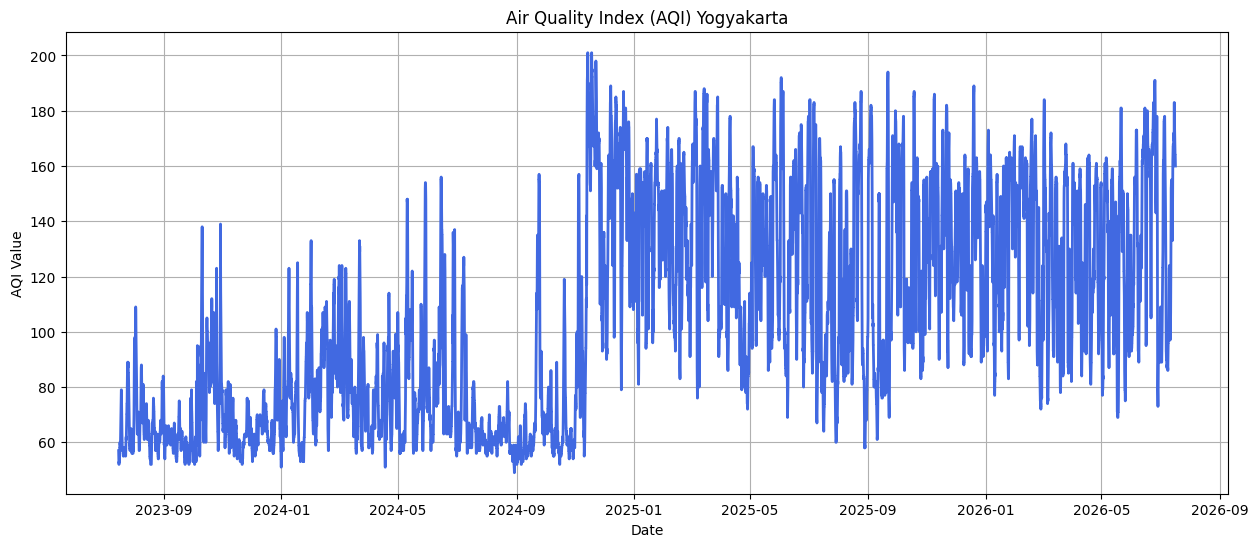

In [ ]:
# visualisasi data historis
plt.figure(figsize=(15, 6))
plt.plot(df['datetime'], df['aqi'], label='AQI', color='royalblue', linewidth=2)
plt.xlabel('Date')
plt.ylabel('AQI Value')
plt.title('Air Quality Index (AQI) Yogyakarta')
plt.grid(True)
plt.show()

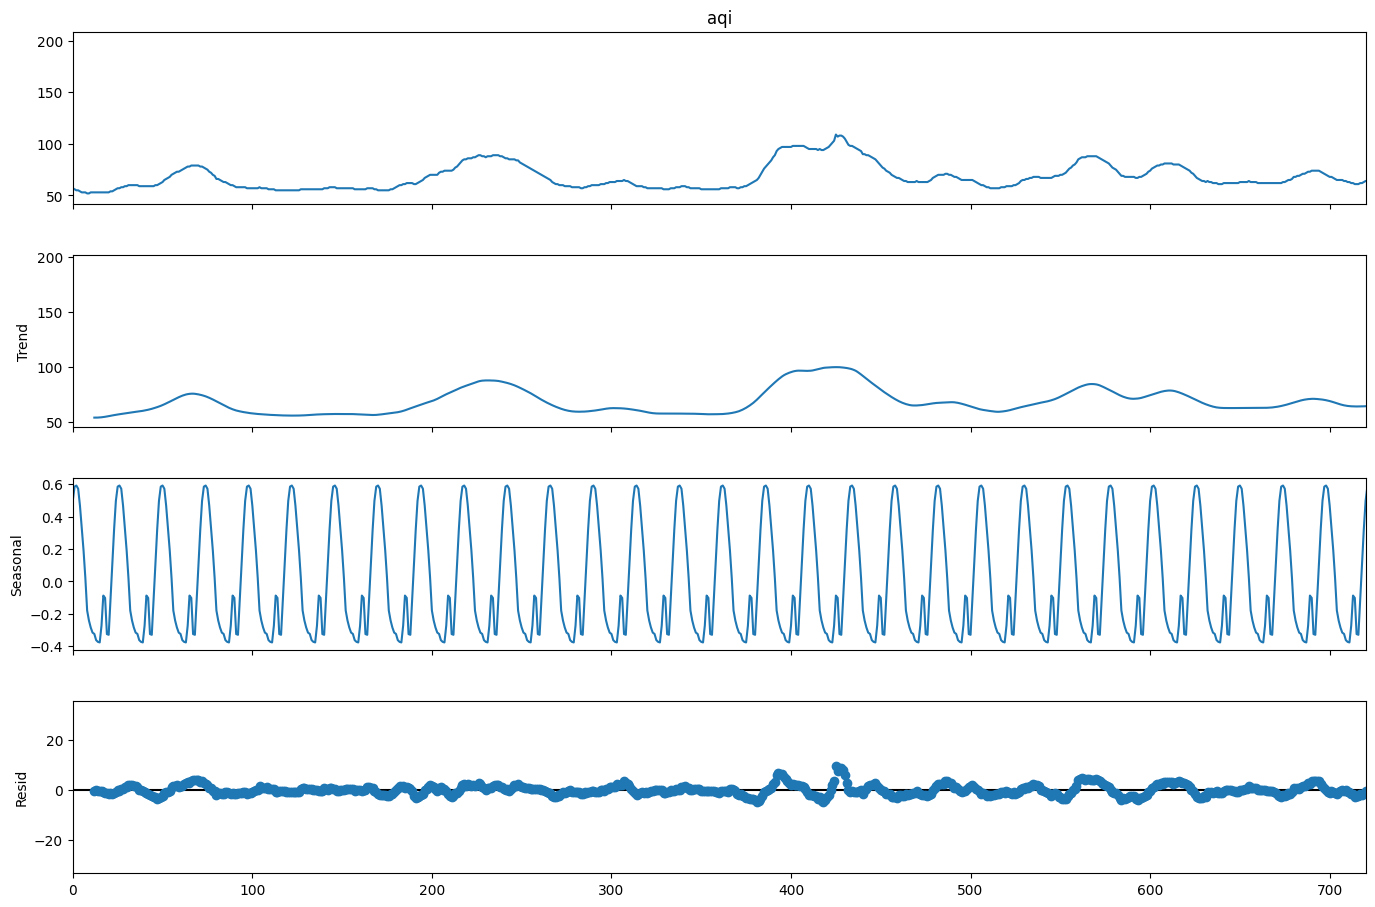

In [ ]:
result = seasonal_decompose(df['aqi'], model='additive', period=24)
fig = result.plot()
fig.set_size_inches(15, 10)
axes = fig.axes
for ax in axes:
    ax.set_xlim(df.index[0], df.index[24*30]) #30 hari
plt.show()

# Data Preprocessing

In [ ]:
# mengubah data menjadi harian
df_daily = (
    df
    .set_index("datetime")
    .resample('D')
    .agg({
        "aqi": "mean",
        "pm10": "mean",
        "pm2_5": "mean",
        "carbon_monoxide": "mean",
        "nitrogen_dioxide": "mean",
        "sulphur_dioxide": "mean",
        "ozone": "mean",
        "temperature_2m": "mean",
        "relative_humidity_2m": "mean",
        "precipitation": "sum",
        "surface_pressure": "mean",
        "cloud_cover": "mean",
        "wind_speed_10m": "mean",
        "wind_direction_10m": "mean" # Ensure wind_direction_10m is included
      })
      .reset_index()
)

In [ ]:
df_daily = df_daily.round(2)

In [ ]:
df_daily.head()

,datetime,aqi,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,cloud_cover,wind_speed_10m
0,2023-07-16,53.58,18.29,12.23,270.62,6.41,2.84,43.83,24.34,82.38,2.6,1000.44,69.75,7.10
1,2023-07-17,58.96,21.94,14.67,339.62,7.70,3.38,44.21,24.16,77.75,0.2,999.67,67.17,6.78
2,2023-07-18,72.58,34.83,23.68,497.04,9.43,4.99,51.12,24.50,76.50,0.0,999.77,32.88,5.83
3,2023-07-19,65.38,19.75,13.03,276.58,6.24,2.50,47.71,24.44,74.04,0.0,999.97,19.67,8.40
4,2023-07-20,56.33,17.50,11.49,316.54,6.90,3.25,48.67,23.82,77.58,0.2,999.96,37.00,7.80


# Feature Engineering

In [ ]:
df_model = df_daily.copy()

In [ ]:
# fitur tanggal
df_model["year"] = df_model["datetime"].dt.year
df_model["month"] = df_model["datetime"].dt.month
df_model["day"] = df_model["datetime"].dt.day
df_model["dayofweek"] = df_model["datetime"].dt.dayofweek
df_model["dayofyear"] = df_model["datetime"].dt.dayofyear
df_model["weekofyear"] = (df_model["datetime"].dt.isocalendar().week.astype(int))
df_model["quarter"] = df_model["datetime"].dt.quarter
df_model["is_weekend"] = (df_model["dayofweek"] >= 5).astype(int)

In [ ]:
# fitur lag
df_model["aqi_lag1"] = df_model["aqi"].shift(1)
df_model["aqi_lag2"] = df_model["aqi"].shift(2)
df_model["aqi_lag3"] = df_model["aqi"].shift(3)
df_model["aqi_lag7"] = df_model["aqi"].shift(7)
df_model["aqi_lag14"] = df_model["aqi"].shift(14)
df_model["aqi_lag30"] = df_model["aqi"].shift(30)

In [ ]:
# fitur rolling
df_model["aqi_rolling_mean_3"] = df_model["aqi"].shift(1).rolling(window=3).mean()
df_model["aqi_rolling_mean_7"] = df_model["aqi"].shift(1).rolling(window=7).mean()
df_model["aqi_rolling_mean_14"] = df_model["aqi"].shift(1).rolling(window=14).mean()
df_model["aqi_rolling_mean_30"] = df_model["aqi"].shift(1).rolling(window=30).mean()

In [ ]:
# fitur lag polutan dan cuaca
external_columns = [
    "pm10",
    "pm2_5",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "surface_pressure",
    "cloud_cover",
    "wind_speed_10m"
]

for col in external_columns:
    df_model[f"{col}_lag_1"] = (
        df_model[col].shift(1)
    )

    df_model[f"{col}_lag_7"] = (
        df_model[col].shift(7)
    )

In [ ]:
df_model.isnull().sum()

,0
datetime,0
aqi,0
pm10,0
pm2_5,0
carbon_monoxide,0
nitrogen_dioxide,0
sulphur_dioxide,0
ozone,0
temperature_2m,0
relative_humidity_2m,0


In [ ]:
# isi nilai kosong dengan 0
df_model = df_model.fillna(0)

In [ ]:
df_model.isnull().sum()

,0
datetime,0
aqi,0
pm10,0
pm2_5,0
carbon_monoxide,0
nitrogen_dioxide,0
sulphur_dioxide,0
ozone,0
temperature_2m,0
relative_humidity_2m,0


In [ ]:
df_model.duplicated().sum()

np.int64(0)

In [ ]:
df_model.head()

,datetime,aqi,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,temperature_2m,relative_humidity_2m,...,relative_humidity_2m_lag_1,relative_humidity_2m_lag_7,precipitation_lag_1,precipitation_lag_7,surface_pressure_lag_1,surface_pressure_lag_7,cloud_cover_lag_1,cloud_cover_lag_7,wind_speed_10m_lag_1,wind_speed_10m_lag_7
0,2023-07-16,53.58,18.29,12.23,270.62,6.41,2.84,43.83,24.34,82.38,...,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.00,0.0
1,2023-07-17,58.96,21.94,14.67,339.62,7.70,3.38,44.21,24.16,77.75,...,82.38,0.0,2.6,0.0,1000.44,0.0,69.75,0.0,7.10,0.0
2,2023-07-18,72.58,34.83,23.68,497.04,9.43,4.99,51.12,24.50,76.50,...,77.75,0.0,0.2,0.0,999.67,0.0,67.17,0.0,6.78,0.0
3,2023-07-19,65.38,19.75,13.03,276.58,6.24,2.50,47.71,24.44,74.04,...,76.50,0.0,0.0,0.0,999.77,0.0,32.88,0.0,5.83,0.0
4,2023-07-20,56.33,17.50,11.49,316.54,6.90,3.25,48.67,23.82,77.58,...,74.04,0.0,0.0,0.0,999.97,0.0,19.67,0.0,8.40,0.0


# EDA

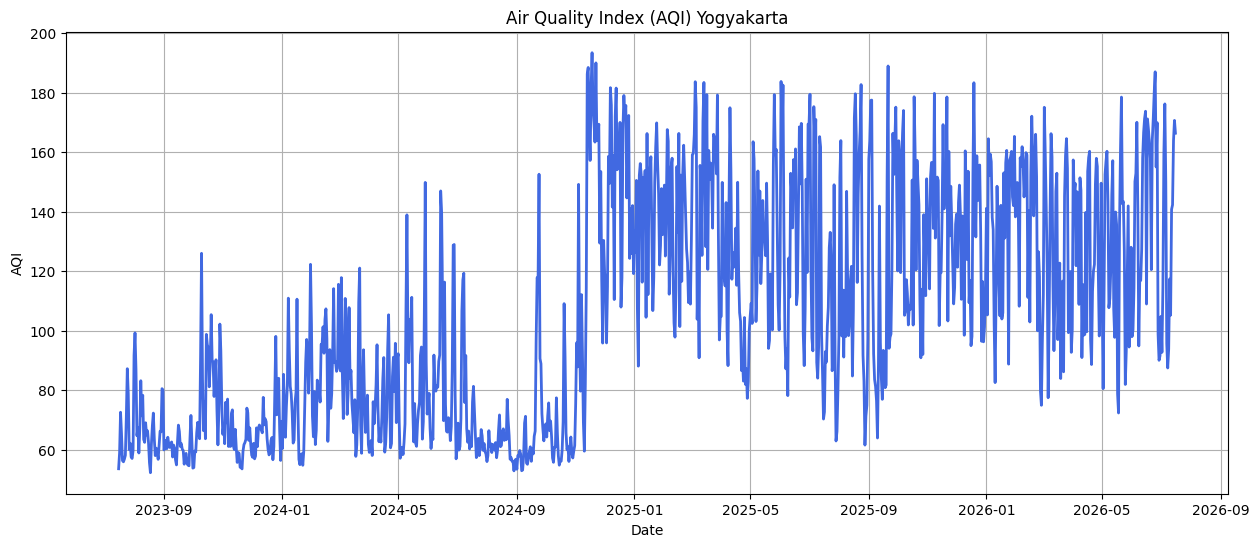

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(df_model['datetime'], df_model['aqi'], label='AQI', color='royalblue', linewidth=2)
plt.title('Air Quality Index (AQI) Yogyakarta')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.grid(True)
plt.show()

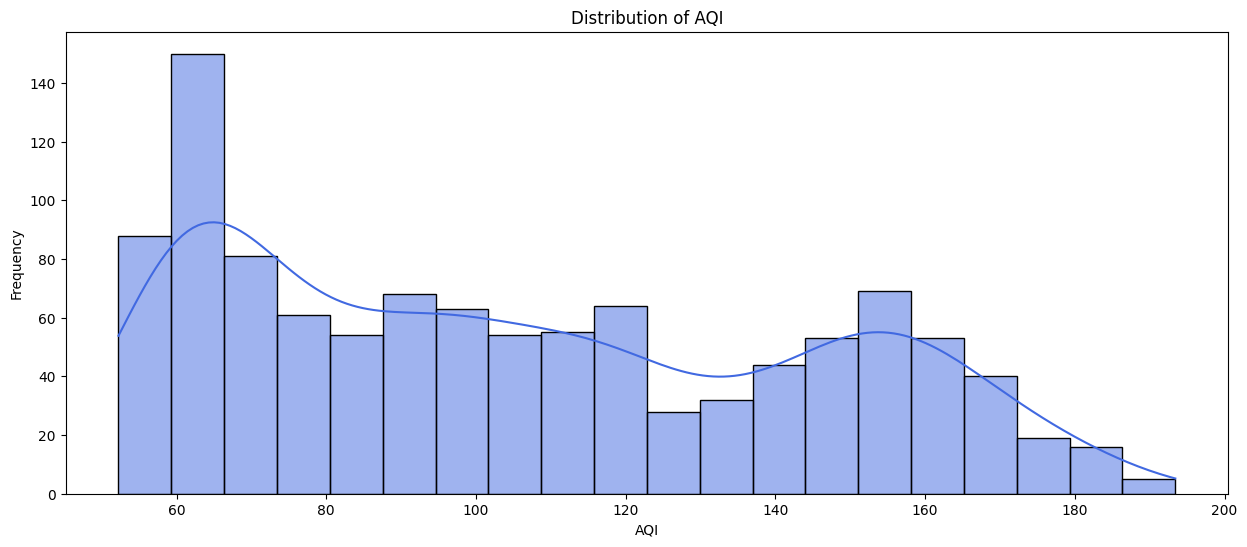

In [ ]:
plt.figure(figsize=(15, 6))
sns.histplot(df_model['aqi'], bins=20, kde=True, color='royalblue')
plt.title('Distribution of AQI')
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_594/3006883799.py:4: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(df_model['datetime'], df_model['aqi'], label='AQI', color='royalblue', linewidth=2)


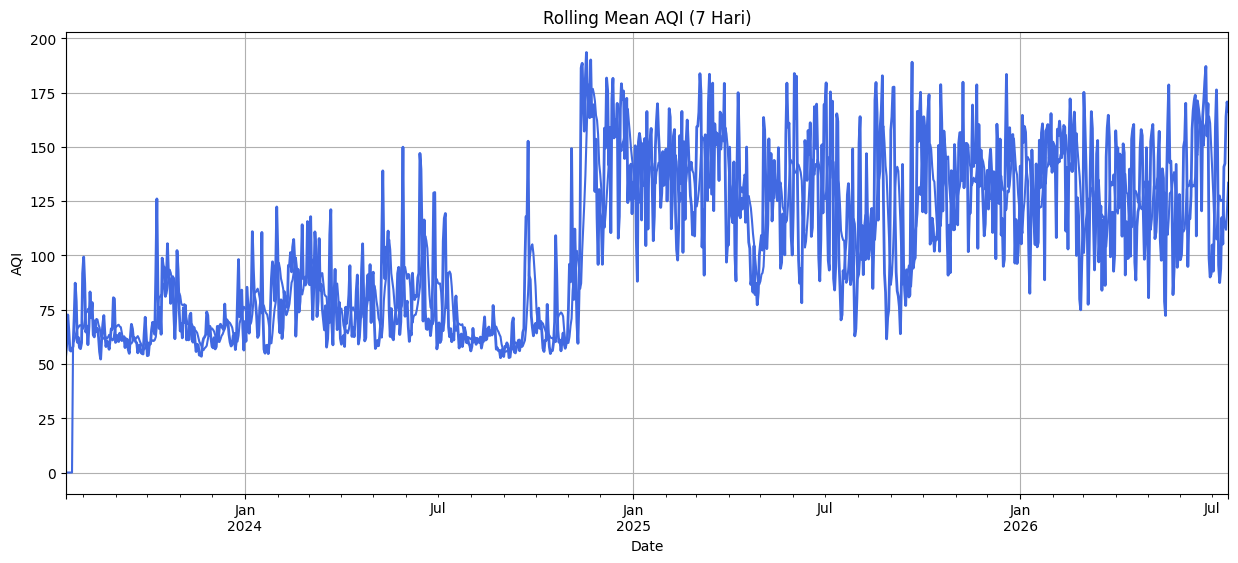

In [ ]:
# rolling mean (7 hari)
plt.figure(figsize=(15, 6))
df_model.set_index('datetime')['aqi_rolling_mean_7'].plot(color='royalblue')
plt.plot(df_model['datetime'], df_model['aqi'], label='AQI', color='royalblue', linewidth=2)
plt.title('Rolling Mean AQI (7 Hari)')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.grid(True)
plt.show()

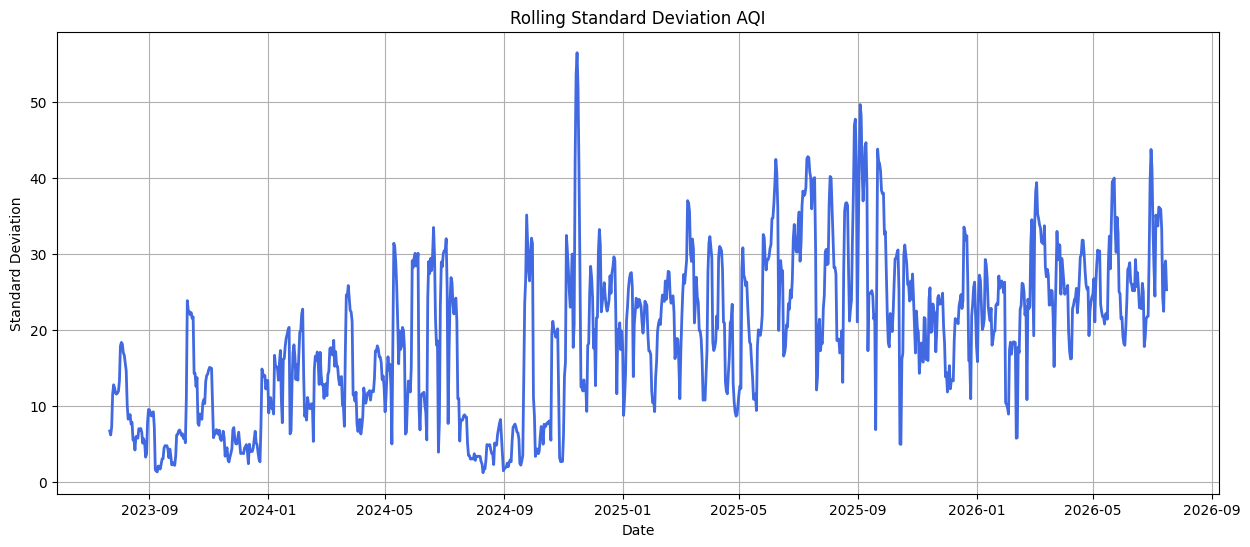

In [ ]:
# rolling standard deviation
rolling_std =(df_model['aqi'].rolling(window=7).std())
plt.figure(figsize=(15, 6))
plt.plot(df_model['datetime'], rolling_std, color='royalblue', linewidth=2)
plt.title('Rolling Standard Deviation AQI')
plt.xlabel('Date')
plt.ylabel('Standard Deviation')
plt.grid(True)
plt.show()

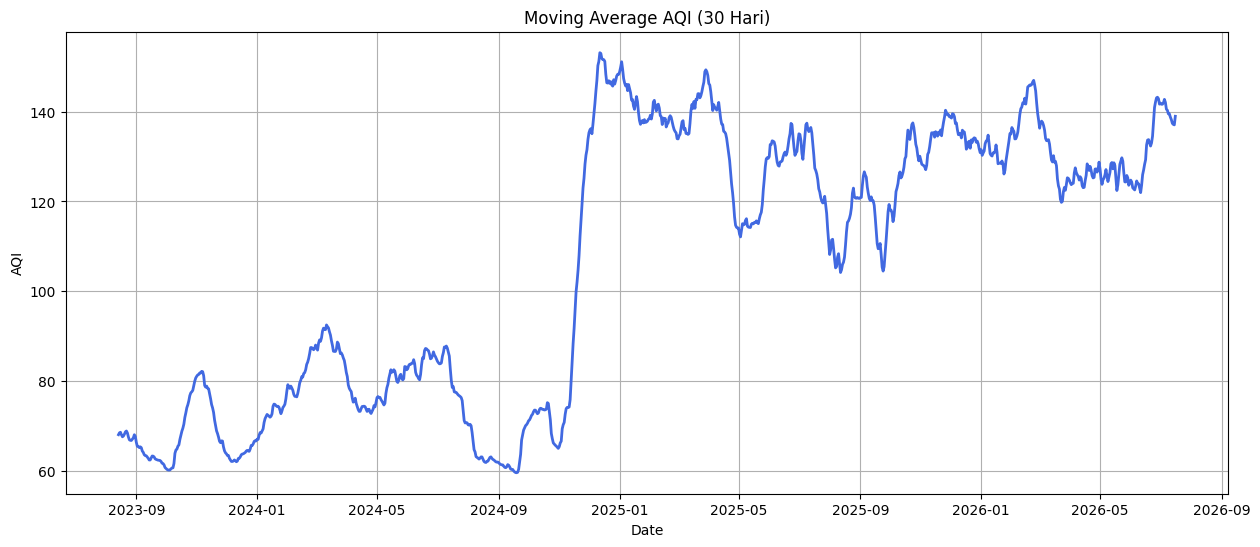

In [ ]:
# moving average (30 hari)
ma30 = df_model['aqi'].rolling(window=30).mean()
plt.figure(figsize=(15, 6))
plt.plot(df_model['datetime'], ma30, color='royalblue', linewidth=2)
plt.title('Moving Average AQI (30 Hari)')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.grid(True)
plt.show()

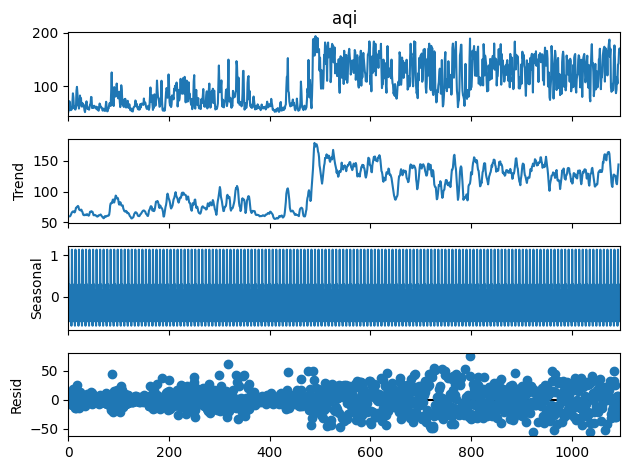

In [ ]:
# seasonality mingguan
decomposition = seasonal_decompose(df_model['aqi'], model='additive', period=7)
decomposition.plot()
plt.show()

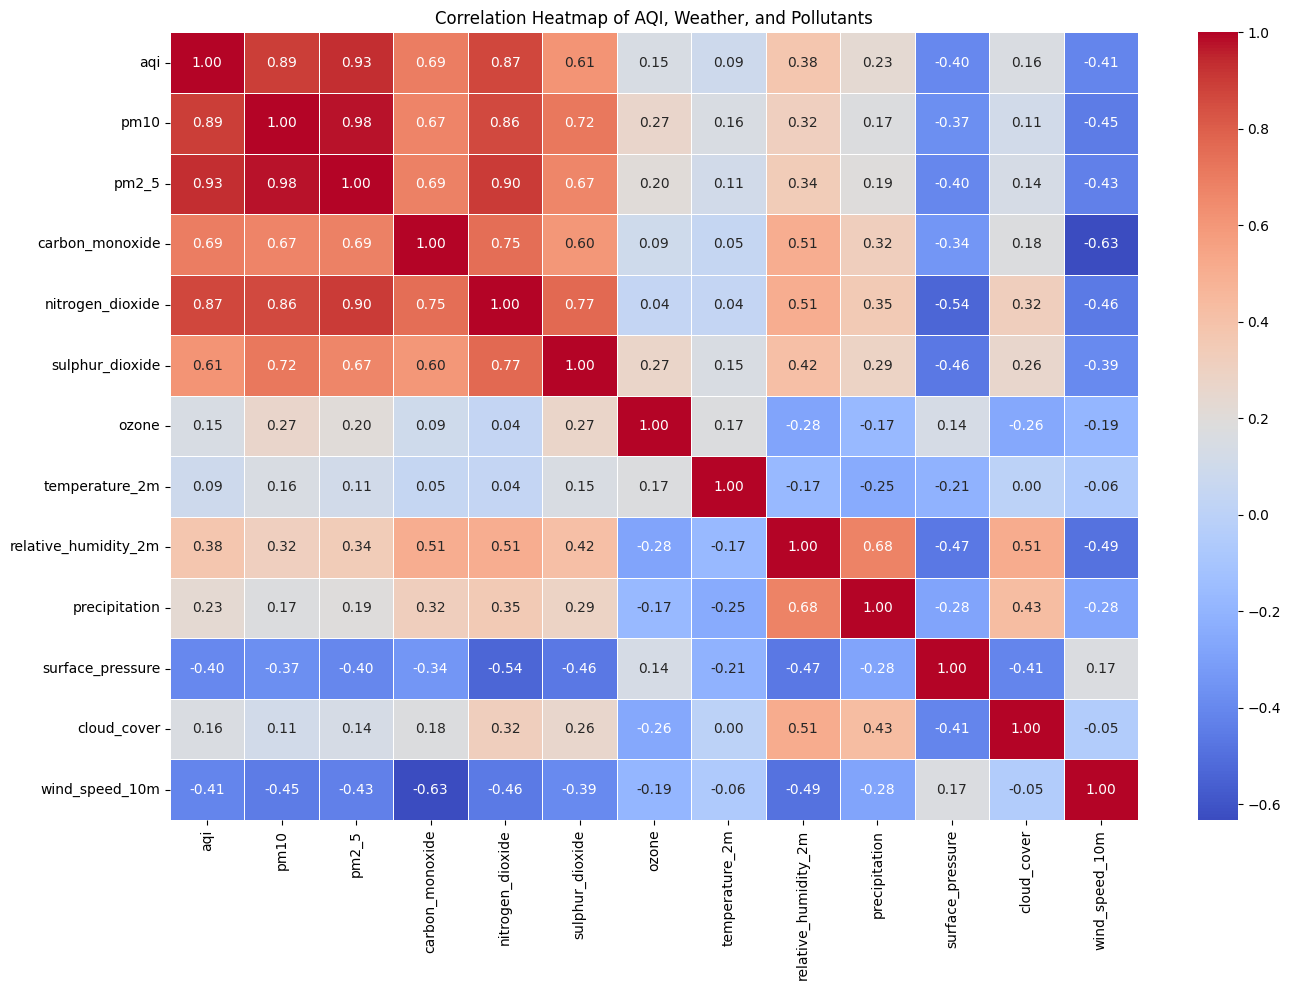

In [ ]:
correlation_cols = [
    'aqi', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide',
    'sulphur_dioxide', 'ozone', 'temperature_2m', 'relative_humidity_2m',
    'precipitation', 'surface_pressure', 'cloud_cover', 'wind_speed_10m'
]

corr_matrix = df_model[correlation_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of AQI, Weather, and Pollutants')
plt.tight_layout()
plt.show()

# Modeling

## Train Test Split

In [ ]:
test_size = 90 #menggunakan 90 hari terakhir data test
train = df_model.iloc[:-test_size].copy()
test = df_model.iloc[-test_size:].copy()

print("Train:", train.shape)
print("Test :", test.shape)

Train: (1007, 56)
Test : (90, 56)


In [ ]:
target = 'aqi'

In [ ]:
drop_columns = ['datetime','aqi']

In [ ]:
# menentukan fitur
features = [
    col for col in df_model.columns
    if col not in drop_columns
]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

## XGBoost

In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

In [ ]:
# training
xgb_model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# prediksi
xgb_pred = xgb_model.predict(X_test)

In [ ]:
# evaluasi
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

xgb_mape = np.mean(
    np.abs(
        (y_test.values - xgb_pred) /
        np.maximum(np.abs(y_test.values), 1e-8)
    )
) * 100


In [ ]:
# visualisasi
result_test = pd.DataFrame({
    "datetime": test["datetime"],
    "Aktual": y_test.values,
    "Prediksi": xgb_pred
})

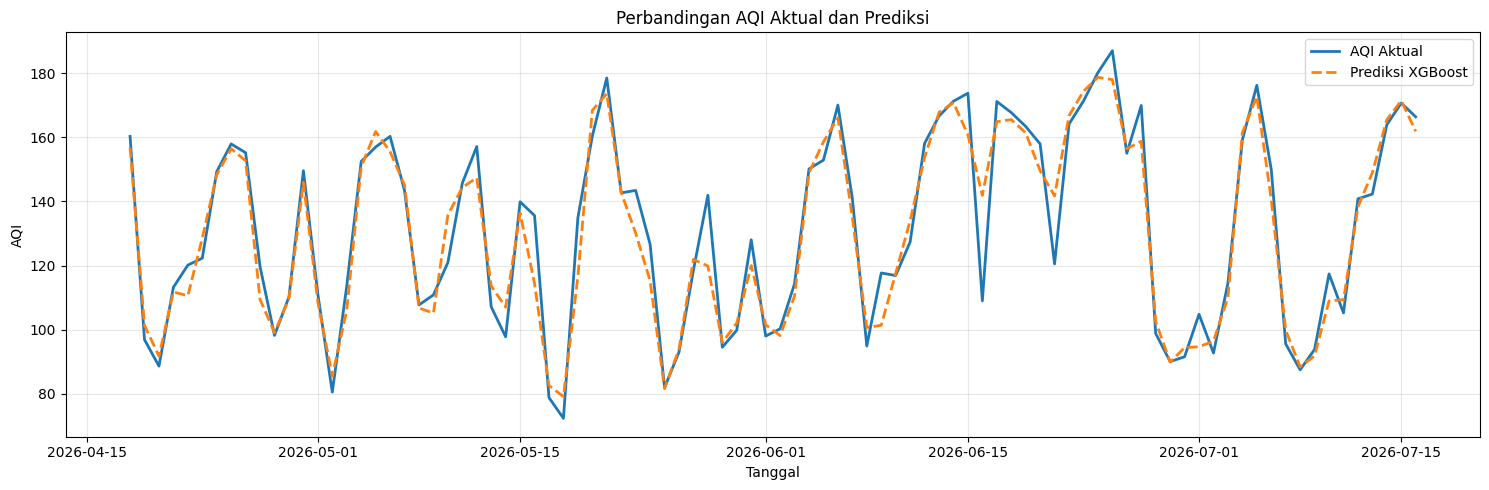

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    result_test["datetime"],
    result_test["Aktual"],
    label="AQI Aktual",
    linewidth=2
)

plt.plot(
    result_test["datetime"],
    result_test["Prediksi"],
    label="Prediksi XGBoost",
    linestyle="--",
    linewidth=2
)

plt.title("Perbandingan AQI Aktual dan Prediksi")
plt.xlabel("Tanggal")
plt.ylabel("AQI")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Sarima

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.9 MB/s eta 0:00:00


In [ ]:
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
auto_arima(y_train,seasonal=True, m=7, trace=True,suppress_warning=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=8988.043, Time=3.77 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=9204.230, Time=0.08 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=9166.030, Time=0.61 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=9128.770, Time=1.38 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=9202.250, Time=0.05 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=8986.052, Time=1.82 sec
 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=8984.090, Time=0.89 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=8986.052, Time=1.65 sec
 ARIMA(1,1,2)(0,0,0)[7] intercept   : AIC=8981.285, Time=0.75 sec
 ARIMA(1,1,2)(1,0,0)[7] intercept   : AIC=8983.274, Time=1.25 sec
 ARIMA(1,1,2)(0,0,1)[7] intercept   : AIC=8983.274, Time=1.45 sec
 ARIMA(1,1,2)(1,0,1)[7] intercept   : AIC=8985.272, Time=1.75 sec
 ARIMA(0,1,2)(0,0,0)[7] intercept   : AIC=9010.780, Time=0.42 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=8982.323, Time=1.39 sec
 ARIMA(1,1,3)(0,0,0)[7] intercept

ARIMA(order=(1, 1, 4), scoring_args={}, seasonal_order=(0, 0, 0, 7),
      suppress_warnings=True, with_intercept=False)

In [ ]:
sarima_model = SARIMAX(y_train, order=(1,1,4), seasonal_order=(0,0,0,7))
sarima_fit = sarima_model.fit()

In [ ]:
# prediksi
sarima_pred = sarima_fit.forecast(len(test))

In [ ]:
# evaluasi
sarima_mae = mean_absolute_error(
    y_test,
    sarima_pred
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        sarima_pred
    )
)

sarima_mape = np.mean(
    np.abs(
        (y_test.values - sarima_pred) /
        np.maximum(np.abs(y_test.values), 1e-8)
    )
) * 100


In [ ]:
# visualisasi
result_test = pd.DataFrame({
    "datetime": test["datetime"],
    "Aktual": y_test.values,
    "Prediksi": sarima_pred
})

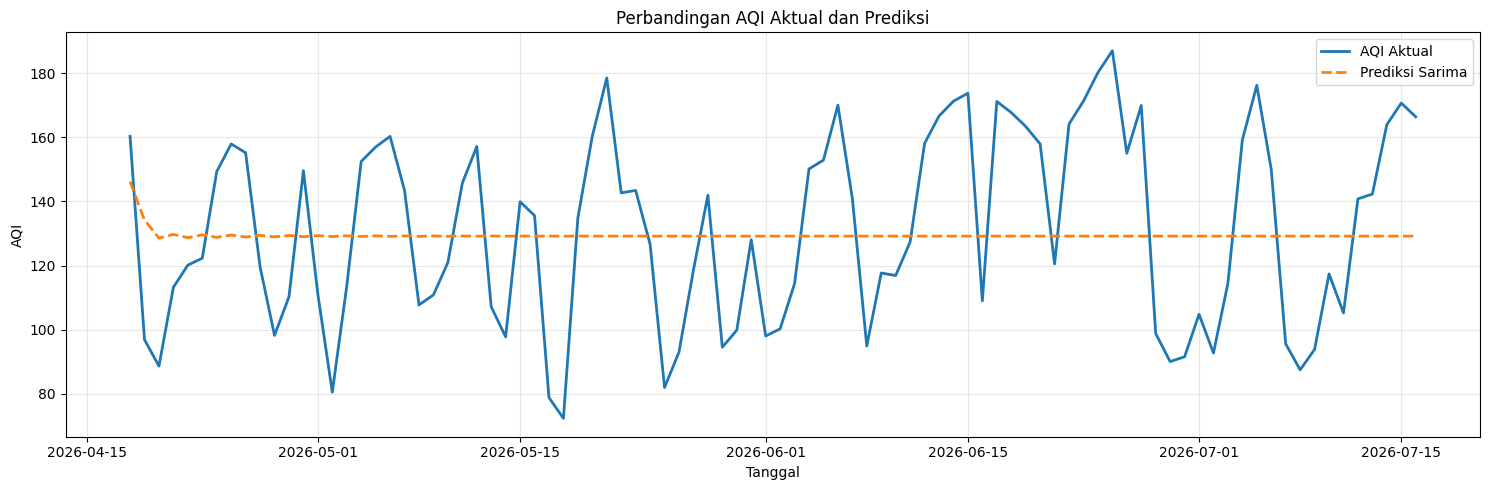

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    result_test["datetime"],
    result_test["Aktual"],
    label="AQI Aktual",
    linewidth=2
)

plt.plot(
    result_test["datetime"],
    result_test["Prediksi"],
    label="Prediksi Sarima",
    linestyle="--",
    linewidth=2
)

plt.title("Perbandingan AQI Aktual dan Prediksi")
plt.xlabel("Tanggal")
plt.ylabel("AQI")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluasi Model

In [ ]:
evaluation = pd.DataFrame({
    "Model": [
        "Sarima",
        "XGBoost"
    ],
    "MAE": [
        sarima_mae,
        xgb_mae
    ],
    "RMSE": [
        sarima_mae,
        xgb_rmse
    ],
    "MAPE": [
        sarima_mape,
        xgb_mape
    ]
})

evaluation

,Model,MAE,RMSE,MAPE
0,Sarima,26.579351,26.579351,21.754069
1,XGBoost,5.633691,7.975166,4.477319


## Training Ulang model terbaik

In [ ]:
X_full = df_model[features]
y_full = df_model['aqi']

In [ ]:
final_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

final_model.fit(
    X_full,
    y_full
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

# Forecasting

In [ ]:
def recursive_forecast(
    model,
    history_df,
    features,
    horizon=7
):
    history = history_df.copy()
    forecasts = []

    for _ in range(horizon):

        next_date = (
            history["datetime"].max()
            + pd.Timedelta(days=1)
        )

        new_row = {}

        new_row["datetime"] = next_date

        external_cols = [
            "pm10",
            "pm2_5",
            "carbon_monoxide",
            "nitrogen_dioxide",
            "sulphur_dioxide",
            "ozone",
            "temperature_2m",
            "relative_humidity_2m",
            "precipitation",
            "surface_pressure",
            "cloud_cover",
            "wind_speed_10m"
        ]

        for col in external_cols:
            new_row[col] = (
                history[col]
                .tail(7)
                .mean()
            )

        new_row["year"] = next_date.year
        new_row["month"] = next_date.month
        new_row["day"] = next_date.day
        new_row["dayofweek"] = next_date.dayofweek
        new_row["dayofyear"] = next_date.dayofyear
        new_row["weekofyear"] = next_date.isocalendar().week
        new_row["quarter"] = next_date.quarter
        new_row["is_weekend"] = int(
            next_date.dayofweek >= 5
        )

        for lag in [1, 2, 3, 7, 14, 30]:
            new_row[f"aqi_lag{lag}"] = ( # Corrected name: removed underscore
                history["aqi"]
                .iloc[-lag]
            )

        for window in [3, 7, 14, 30]:
            aqi_history = history["aqi"]

            new_row[f"aqi_rolling_mean_{window}"] = (
                aqi_history.tail(window).mean()
            )

        for col in external_columns:
            new_row[f"{col}_lag_1"] = (
                history[col].iloc[-1]
            )

            new_row[f"{col}_lag_7"] = (
                history[col].iloc[-7]
            )

        future_X = pd.DataFrame(
            [new_row]
        )[features]

        predicted_aqi = model.predict(
            future_X
        )[0]

        new_row["aqi"] = max(
            0,
            predicted_aqi
        )

        history = pd.concat(
            [
                history,
                pd.DataFrame([new_row])
            ],
            ignore_index=True
        )

        forecasts.append({
            "datetime": next_date,
            "Prediksi_AQI": round(
                predicted_aqi,
                2
            )
        })

    return pd.DataFrame(forecasts)

In [ ]:
# 7 hari
forecast_7 = recursive_forecast(
    final_model,
    df_model,
    features,
    horizon=7
)

forecast_7

,datetime,Prediksi_AQI
0,2026-07-17,157.610001
1,2026-07-18,153.889999
2,2026-07-19,160.080002
3,2026-07-20,160.660004
4,2026-07-21,162.529999
5,2026-07-22,162.089996
6,2026-07-23,162.770004


In [ ]:
# 14 hari
forecast_14 = recursive_forecast(
    final_model,
    df_model,
    features,
    horizon=14
)
forecast_14

,datetime,Prediksi_AQI
0,2026-07-17,157.610001
1,2026-07-18,153.889999
2,2026-07-19,160.080002
3,2026-07-20,160.660004
4,2026-07-21,162.529999
5,2026-07-22,162.089996
6,2026-07-23,162.770004
7,2026-07-24,161.960007
8,2026-07-25,161.050003
9,2026-07-26,161.130005


In [ ]:
# 30 hari
forecast_30 = recursive_forecast(
    final_model,
    df_model,
    features,
    horizon=30
)
forecast_30

,datetime,Prediksi_AQI
0,2026-07-17,157.610001
1,2026-07-18,153.889999
2,2026-07-19,160.080002
3,2026-07-20,160.660004
4,2026-07-21,162.529999
5,2026-07-22,162.089996
6,2026-07-23,162.770004
7,2026-07-24,161.960007
8,2026-07-25,161.050003
9,2026-07-26,161.130005


In [ ]:
# membuat kategori aqi
def aqi_category(aqi):
    if aqi <= 50:
        return "Baik"
    elif aqi <= 100:
        return "Sedang"
    elif aqi <= 150:
        return "Tidak Sehat untuk Kelompok Sensitif"
    elif aqi <= 200:
        return "Tidak Sehat"
    elif aqi <= 300:
        return "Sangat Tidak Sehat"
    else:
        return "Berbahaya"

In [ ]:
forecast_30["Kategori"] = (
    forecast_30["Prediksi_AQI"]
    .apply(aqi_category)
)

forecast_30.head()

,datetime,Prediksi_AQI,Kategori
0,2026-07-17,157.610001,Tidak Sehat
1,2026-07-18,153.889999,Tidak Sehat
2,2026-07-19,160.080002,Tidak Sehat
3,2026-07-20,160.660004,Tidak Sehat
4,2026-07-21,162.529999,Tidak Sehat


In [ ]:
# simpan
forecast_30.to_csv(
    "forecast_aqi_30_hari.csv",
    index=False
)

In [ ]:
# menyimpan model
import joblib

joblib.dump(
    final_model,
    "aqi_xgboost_model.pkl"
)

joblib.dump(
    features,
    "model_features.pkl"
)

joblib.dump(
    df_model,
    "historical_data.pkl"
)

evaluation_metrics = {
    "MAE": float(xgb_mae),
    "RMSE": float(xgb_rmse),
    "MAPE": float(xgb_mape)
}

joblib.dump(
    evaluation_metrics,
    "evaluation_metrics.pkl"
)

['evaluation_metrics.pkl']

In [ ]:
test_prediction = pd.DataFrame({
    "datetime": test["datetime"].values,
    "Aktual": y_test.values,
    "Prediksi": xgb_pred
})

test_prediction["datetime"] = pd.to_datetime(
    test_prediction["datetime"]
)

joblib.dump(
    test_prediction,
    "test_prediction.pkl"
)

['test_prediction.pkl']

In [ ]:
import joblib

forecast_results = {
    7: forecast_7.copy(),
    14: forecast_14.copy(),
    30: forecast_30.copy()
}

joblib.dump(
    forecast_results,
    "forecast_results.pkl"
)

print("Forecast 7, 14, dan 30 hari berhasil disimpan.")

Forecast 7, 14, dan 30 hari berhasil disimpan.
